Slope: -0.2609357461136233, Intercept: 5.480928437075681
My Slope: -0.2609357461136248,My Intercept: 5.480928437075688


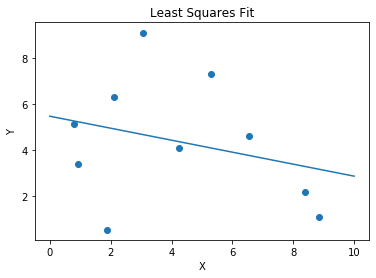

In [15]:
import numpy as np
from numpy import random
import matplotlib.pyplot as plt


#Random Vectors    
X = np.random.uniform(low=0.0, high=10., size= 10)
X= np.sort(X)

Y= np.random.uniform(low=0.0, high=10., size= 10)
A = np.vstack([X, np.ones(len(X))]).T

#Numpy's Least Square
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Slope: {m}, Intercept: {c}")

 #My least-square algo based on the slides
def least_square(X,Y):
    n = len(X)
    
    #Step 1: Summations
    sum_X = np.sum(X)
    sum_Y = np.sum(Y)
    sum_X2 = np.sum(X**2)
    sum_XY = np.sum(X*Y)
    
    #Step 2: Compute m,c
    m = (n * sum_XY - sum_X * sum_Y)/ (n *sum_X2 - sum_X**2)
    c = (sum_Y - m * sum_X) /n
    
    return m,c
    
my_m, my_c = least_square(X,Y)
    
print(f"My Slope: {my_m},My Intercept: {my_c}")
    
plt.scatter(X, Y)
x = np.linspace(0, 10, 10000)
plt.title("Least Squares Fit")
plt.xlabel("X")
plt.ylabel("Y")
plt.plot(x, m*x+c)
plt.show()

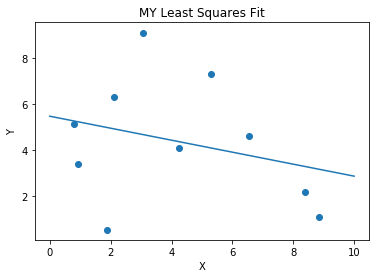

In [16]:
plt.scatter(X, Y)
plt.title("MY Least Squares Fit")
plt.xlabel("X")
plt.ylabel("Y")
plt.plot(x, my_m*x+ my_c)
plt.show()

Almost exactly the same!

Slope: 1.8076996378603356, Intercept: 1.2719017437021345
My Slope: 1.8076996378603374,My Intercept: 1.271901743702133


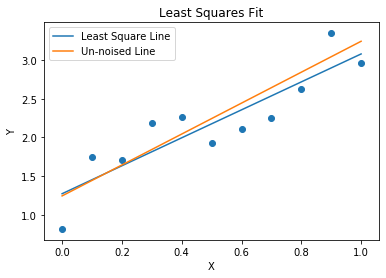

In [17]:
X = np.linspace(0, 1, 11)
noise = np.random.uniform(-0.5, 0.5, len(X)) #Random Pertubation

Y = 2*X + 1.243565 + noise

A = np.vstack([X, np.ones(len(X))]).T

m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Slope: {m}, Intercept: {c}")

my_m, my_c = least_square(X,Y)
print(f"My Slope: {my_m},My Intercept: {my_c}")


plt.scatter(X, Y)
x = np.linspace(0, 1, 1000)
plt.title("Least Squares Fit")
plt.xlabel("X")
plt.ylabel("Y")
plt.plot(x, m*x+c, label = "Least Square Line")
plt.plot(X, 2*X + 1.243565, label = "Un-noised Line")
plt.legend()
plt.show()

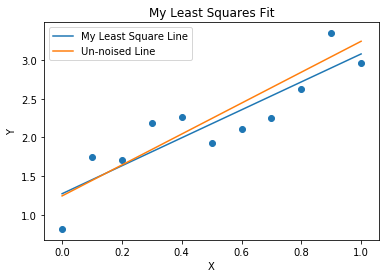

In [18]:
plt.scatter(X, Y)
plt.title("My Least Squares Fit")
plt.xlabel("X")
plt.ylabel("Y")
plt.plot(x, my_m*x+ my_c, label = "My Least Square Line")
plt.plot(X, 2*X + 1.243565, label = "Un-noised Line")
plt.legend()
plt.show()

Also pretty close

In [19]:
y_pred = my_m * X + my_c
residuals = Y - y_pred

In [20]:
max_idx = np.argmax(np.abs(residuals)) #Asked ChatGPT for this
min_idx = np.argmin(np.abs(residuals)) #Returns the index of the lowest mag. residual and highest mag residual

print("\n Residuals:")
print(residuals)

print("\nLargest Residual:")
print(f"Point ({X[max_idx]:.3f}, {Y[max_idx]:.3f}) Residual = {residuals[max_idx]:.4f}")

print("\nSmallest Residual:")
print(f"Point ({X[min_idx]:.3f}, {Y[min_idx]:.3f}) Residual = {residuals[min_idx]:.4f}")



 Residuals:
[-0.4544409   0.29311391  0.07172038  0.3705121   0.26316783 -0.24875203
 -0.25264898 -0.28508652 -0.08901082  0.44766642 -0.11624138]

Largest Residual:
Point (0.000, 0.817) Residual = -0.4544

Smallest Residual:
Point (0.200, 1.705) Residual = 0.0717


Looks small enough.